## Act 1: Freeze & Fix the Scenario Baseline

#### Step 1A: Scenario Card (`UC-05: Record Activity`)

* Focal Scenario: `UC-05: Record Activity`
* Primary Actor: `Participant`
* Trigger: `Participant` submits activity logging parameters (`participant_id`, `challenge_id`, `activity_type`, `amount`, `activity_date`, optional `note`).
* Preconditions:
  1. `Participant` entity exists in persistent storage (`participant_id`).
  2. Target `Challenge` entity exists in persistent storage (`challenge_id`).
  3. Active `Enrollment` record exists linkng `participant_id` and `challenge_id` (`FB-03`).
  4. Submitted `activity_date` falls within the challenge active dates (`start_date` $\le$ `activity_date` $\le$ `end_date`).
* Success Postcondition: Exactly one new `ActivityRecord` entity is constructed, appended to `activities.csv`, and persistently saved. The participant's `ProgressSummary` (`total`, `percentage`, `status`) is dynamically recalculated and returned (`FB-02`, `FB-05`, `FB-07`)
* Failure Postconditions: Submission is rejected with an explicit, field-specific `ValueError` (e.g., `'Participant is not enrolled'`, `'Amount must be positive'`, `'Activity type does not match challenge'`). Zero records are appended to `activities.csv`, and all stored data and progress metrics remain strictly unchanged (`FB-04`, `NFB-02`).
* Core Invariant (State Protection Rule): No rejected or invalid request shall alter stored activity logs, database states, or calculated progress totals (`FB-04`)

#### Step 1B: Chronological Event Inventory (`UC-05: Record Activity`)

| Event # | Chronological Action / Event | Actor / Originator | Internal Mechanism & Validation | Needed Evidence / Assertion | Observable Result | State-Change Flag |
| :---: | :--- | :--- | :--- | :--- | :--- | :---: |
| E-01 | Submit Activity Details | `Participant` | Intercept submission parameters (`participant_id`, `challenge_id`, `activity_type`, `amount`, `date`, `note`). | Parameter tuple passed to `ChallengeHub` UI layer. | CLI input prompt captured. | No |
| E-02 | Locate System Identities | `ChallengeHub` UI | Query `ChallengeManager` to locate `Participant` (`P001`) and `Challenge` (`C001`) entities. | `manager.get_participant()` & `manager.get_challenge()`. | Target entity instances retrieved or identity error triggered. | No |
| E-03 | Confirm Enrollment Link | `ChallengeManager` | Check if active `Enrollment` record exists linking `participant_id` and `challenge_id` (`FB-03`). | Guard `[Enrollment exists]`. | Active enrollment confirmed; otherwise raises `ValueError("Participant is not enrolled")`. | No |
| E-04 | Validate Business Rules | `ChallengeManager` | Validate `activity_type` matches challenge, `amount > 0` (`FB-04`), and `activity_date` within bounds. | Guard `[amount > 0 and type matches and date valid]`. | All validation checks pass; otherwise raises field-specific `ValueError`. | No |
| E-05 | Construct Entity | `ChallengeManager` | Generate unique `record_id` (e.g., `AR-0004`) and instantiate `ActivityRecord` object in memory. | `ActivityRecord(...)` dataclass constructor. | Memory object created; not yet written to disk. | No |
| E-06 | Persist Activity Record | `ChallengeManager` | Invoke `storage.save_activities()` to append the new record to `activities.csv` (`FB-07`). | CSV row write & file flush; row count increases by 1. | Persistent flat-file updated (`activities.csv`). | YES (State Change) |
| E-07 | Return Confirmation & Progress | `ChallengeManager` | Recalculate participant's `ProgressSummary` and return result to UI (`FB-05`). | `cm.progress("P001", "C001")` returns updated `total` and `percentage`. | Updated progress displayed to participant. | No |

#### STEP 1C: Scenario Card

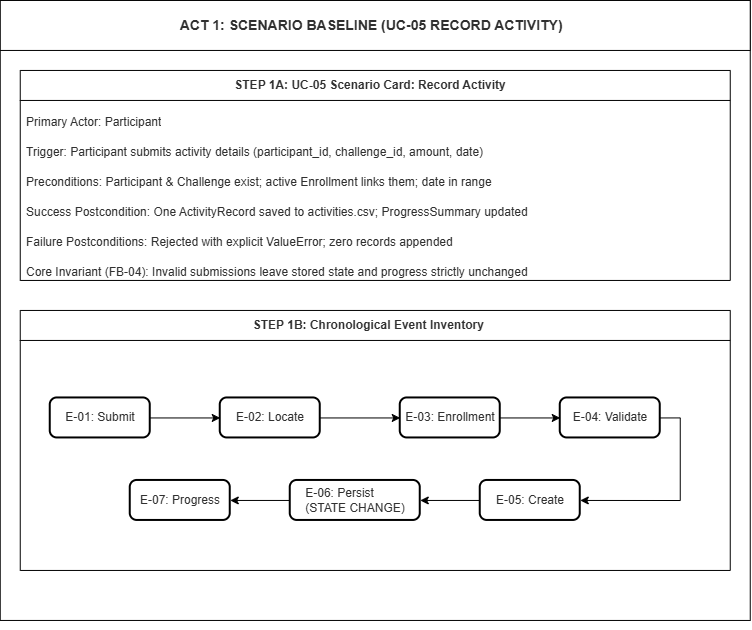

## Act 2: Model Collaboration

### Step 2A: Lifeline Classification, Selection nad Rejection Rationale

| Lifeline Identifier | Role & Architectural Layer | Justification for Selection / Rejection | Status |
| :--- | :--- | :--- | :---: |
| **`:Participant`** | **Actor / Initiator** | Represents the primary human user initiating the `UC-05` activity logging workflow. | **SELECTED** |
| **`:ChallengeHub`** | **System Boundary / UI Layer** | Intercepts user input parameters and renders resulting `ProgressSummary` feedback or exception messages. | **SELECTED** |
| **`:ChallengeManager`** | **Application Coordinator / Controller** | Central service orchestrating identity verification, rule validation, object instantiation, and progress recalculation. | **SELECTED** |
| **`:ActivityRecord`** | **Domain Entity Class** | The memory object instantiated upon successful validation containing `record_id`, `amount`, `activity_date`, etc. | **SELECTED** |
| **`storage`** | **Persistence Infrastructure Module** | Encapsulates flat-file file I/O operations (`save_activities()`) for `activities.csv`. | **SELECTED** |
| *GUI Submit Button* | Presentation Widget | **Rejected:** Overly low-level widget detail that clutters architectural intent. | **REJECTED** |
| *`pandas` DataFrame* | Internal Processing Structure | **Rejected:** Implementation detail encapsulated entirely inside the `storage` module. | **REJECTED** |
| *`activities.csv` File* | Physical Disk Storage | **Rejected:** Physical flat file hidden behind the `storage` persistence interface abstraction. | **REJECTED** |

### Step 2B: Interaction Messages & Sequence Specification Table (`sd Record Activity`)

| Step # | Originating Lifeline | Target Lifeline | Message / Call Signature | Operation Type & Guard Condition | Purpose / Result |
| :---: | :--- | :--- | :--- | :--- | :--- |
| **1** | `:Participant` | `:ChallengeHub` | `submit(details)` | Synchronous Request | Passes input tuple (`participant_id`, `challenge_id`, `activity_type`, `amount`, `date`, `note`). |
| **2** | `:ChallengeHub` | `:ChallengeManager` | `record_activity(participant_id, challenge_id, activity_type, amount, date, note)` | Synchronous Call | Delegates execution to application controller. |
| **3** | `:ChallengeManager` | `:ChallengeManager` | `locate_and_validate_identities()` | Self-Call | Verifies `Participant` and `Challenge` entities exist. |
| **4** | `:ChallengeManager` | `:ChallengeManager` | `verify_enrollment()` | Self-Call / Guard: `[Enrollment exists]` | Confirms active link between participant and challenge (`FB-03`). |
| **5** | `:ChallengeManager` | `:ChallengeManager` | `validate_business_rules()` | Self-Call / Guard: `[amount > 0 and type matches and date in range]` | Validates positive amount (`FB-04`), activity type match, and active date window. |
| **6** | `:ChallengeManager` | `:ActivityRecord` | `create(record_id, participant_id, challenge_id, activity_type, amount, date, note)` | Object Creation (`<<create>>`) | Instantiates `ActivityRecord` dataclass in memory. |
| **7** | `:ChallengeManager` | `storage` | `save_activities(records)` | Persistence Invocation | Appends new record to `activities.csv` ($\Delta \text{rows} = +1$) (`FB-07`). |
| **8** | `:ChallengeManager` | `:ChallengeManager` | `recalculate_progress()` | Self-Call | Recomputes participant `ProgressSummary` (`FB-05`). |
| **9** | `:ChallengeManager` | `:ChallengeHub` | `return ProgressSummary(total, percentage, status)` | Return Message | Returns dynamic progress object to boundary layer. |
| **10** | `:ChallengeHub` | `:Participant` | `display_success(ProgressSummary)` | User Feedback | Renders updated completion percentage to participant. |

### Step 2C: Guarded Alternative Combined Fragments (`alt`)

The sequence diagram incorporates a combined fragment (`alt`) with three mutually exclusive execution paths:

### 1. `alt [Identity or Enrollment Missing]` (Exception Branch 1)
* **Guard:** `[participant_id or challenge_id not found OR enrollment record missing]`
* **Sequence:** `:ChallengeManager` intercepts missing link $\rightarrow$ raises `ValueError("Participant is not enrolled")` $\rightarrow$ control returns immediately to `:ChallengeHub`.
* **State Protection (`FB-04`):** `storage.save_activities()` is **never called**. $\Delta \text{rows} = 0$, stored records and progress totals remain strictly unchanged.

### 2. `alt [Invalid Amount / Type Mismatch / Date Out-of-Bounds]` (Exception Branch 2)
* **Guard:** `[amount <= 0 OR activity_type != challenge.activity_type OR date outside bounds]`
* **Sequence:** `:ChallengeManager` intercepts rule violation $\rightarrow$ raises field-specific `ValueError` (e.g., `'Amount must be positive'`) $\rightarrow$ returns error string to `:ChallengeHub`.
* **State Protection (`FB-04`):** `storage.save_activities()` is **never called**. $\Delta \text{rows} = 0$, zero disk writes occur.

### 3. `alt [All Validation Checks Pass]` (Main Success Path)
* **Guard:** `[Enrolled AND amount > 0 AND activity_type matches AND date valid]`
* **Sequence:** `:ChallengeManager` creates `:ActivityRecord` $\rightarrow$ calls `storage.save_activities()` $\rightarrow$ recalculates progress $\rightarrow$ returns `ProgressSummary`

### STEP 2D: Sequence Model


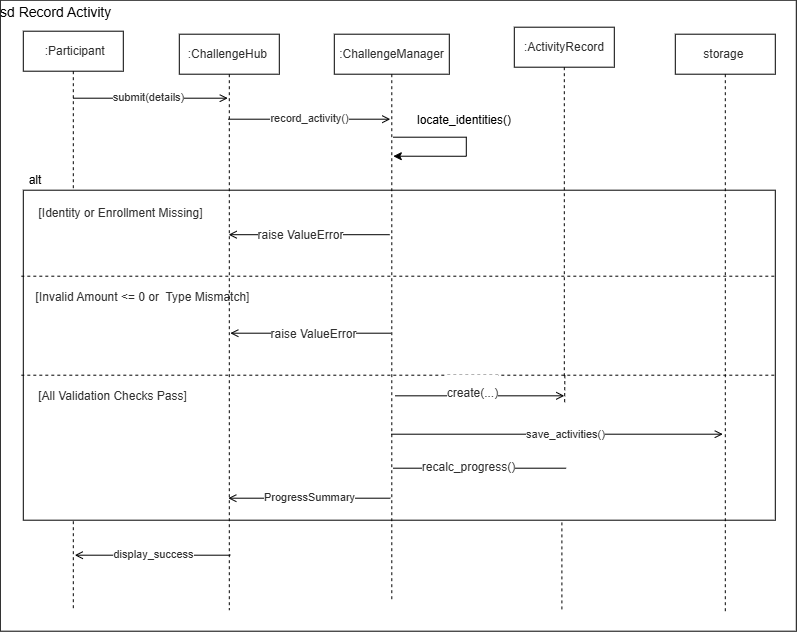

## Act 3:  Model Workflow

### Step 3A: Activity Partitioning (Swimlanes) & Action Node Inventory

| Partition (Swimlane) | Responsible Component | Assigned Actions / Operations | Architectural Layer |
| :--- | :--- | :--- | :--- |
| `Participant` | User Interface / Boundary | 1. `Submit Activity Details`<br>2. `Display Error Notice`<br>3. `Display Confirmation & Progress` | User Boundary / Presentation |
| `ChallengeManager` | Application Service / Controller | 1. `Locate Participant & Challenge`<br>2. `Evaluate Enrollment Status`<br>3. `Validate Amount, Type, & Date`<br>4. `Create ActivityRecord Instance`<br>5. `Recalculate ProgressSummary` | Domain / Business Logic |
| `Storage` | Persistence Infrastructure | 1. `Append & Persist Activity Record (activities.csv)` | Persistence Infrastructure |


### Step 3B: Decision Nodes, Complementary Guards, & Flow Routing

#### Decision Node 1: Enrollment Verification (`FB-03`)
* Input Action: `Evaluate Enrollment Status`
* Guard 1A `[Enrolled]` (Success Path): Participant has an active link with the challenge \\(\rightarrow\\) proceeds to `Validate Amount, Type, & Date`.
* Guard 1B `[Not Enrolled]` (Failure Path): No active enrollment record exists \\(\rightarrow\\) branches directly to `Display Error Notice ("Participant is not enrolled")` \\(\rightarrow\\) terminates at Failure Activity Final Node.
* State Protection Impact (`FB-04`): Bypasses object creation and storage persistence entirely (\\(\Delta \text{rows} = 0\\))

#### Decision Node 2: Business Rule Validation (`FB-04`)
* Input Action:`Validate Amount, Type, & Date`
* Guard 2A `[Valid Amount, Type, & Date]` (Success Path): `amount > 0`, `activity_type` matches challenge, and `activity_date` within active bounds \\(\rightarrow\\) proceeds to `Create ActivityRecord Instance`.
* Guard 2B `[Invalid Amount <= 0, Type Mismatch, or Out-of-Bounds Date]` (Failure Path): One or more business rules violated \\(\rightarrow\\) branches directly to `Display Error Notice ("Amount must be positive" / Field Error)` \\(\rightarrow\\) terminates at Failure Activity Final Node
* State Protection Impact (`FB-04`): Bypasses object creation and storage persistence entirely (\\(\Delta \text{rows} = 0\\)).


### Step 3C: Invariant Enforcement & State Protection Guarantee (`FB-04`)

Formal Invariant Statement:
No invalid or rejected activity logging submission shall alter stored activity records, database states, or calculated progress metrics ($\Delta \text{activities.csv rows} = 0$, $\Delta \text{ProgressSummary} = 0$).

#### 1. Activity Model Control Flow Tracing
* Success Path Trace: `[Initial Node]` $\rightarrow$ `Submit Details` $\rightarrow$ `Locate Entities` $\rightarrow$ `[Enrolled]` $\rightarrow$ `Validate Values` $\rightarrow$ `[Valid Values]` $\rightarrow$ `Construct ActivityRecord` $\rightarrow$ `Append to activities.csv` $\rightarrow$ `Recalculate Progress` $\rightarrow$ `Display Confirmation` $\rightarrow$ `(Success Final Node)`.
* Failure Path 1 Trace (`FB-03` Unlinked Enrollment): `[Initial Node]` $\rightarrow$ `Submit Details` $\rightarrow$ `Locate Entities` $\rightarrow$ `[Not Enrolled]` $\rightarrow$ `Display Error Notice ("Participant is not enrolled")` $\rightarrow$ `(Failure Final Node 1)`
* Failure Path 2 Trace (`FB-04` Invalid Amount/Type): `[Initial Node]` $\rightarrow$ `Submit Details` $\rightarrow$ `Locate Entities` $\rightarrow$ `[Enrolled]` $\rightarrow$ `Validate Values` $\rightarrow$ `[Invalid Values]` $\rightarrow$ `Display Error Notice ("Amount must be positive")` $\rightarrow$ `(Failure Final Node 2)`

#### 2. Architectural Verification & Invariant Proof
1. Swimlane Isolation: The persistence action `Append & Persist Activity Record` is located strictly inside the `Storage` swimlane

2. Control Edge Protection: Neither failure path (`[Not Enrolled]` or `[Invalid Values]`) contains an outgoing control edge connected to `Construct ActivityRecord` or `Storage`
3. State Protection Guarantee: Both failure paths branch directly to presentation error nodes and terminate at Failure Final Nodes, guaranteeing zero disk operations ($\Delta \text{rows} = 0$)